In [3]:
import json
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

import time
import copy

from msro import msro as algo, get_mean_row_front_size

### 1 - Test with the matrix given in the 1999 paper

In [448]:
# m = np.array([[1,0,1,1,0,0],
#               [0,1,0,1,1,0],
#               [1,0,1,1,0,1],
#               [0,1,0,0,0,0],
#               [0,0,0,1,1,1],
#               [0,0,0,0,0,1]])
m = np.array([[1,0,0,1,0,1],
              [0,1,0,0,1,0],
              [0,0,1,0,0,1],
              [0,1,0,0,0,0],
              [0,0,0,0,1,1],
              [1,0,1,1,0,1]])

msro_m = algo(m, perm = "rows")
print(msro_m)

[[1 0 0 1 0 1]
 [1 0 1 1 0 1]
 [0 0 1 0 0 1]
 [0 0 0 0 1 1]
 [0 1 0 0 1 0]
 [0 1 0 0 0 0]]


### 2 - Test with a `150x150` matrix taken from a random 3-SAT problem with `alpha` = 1

In [450]:
N = 150
alpha = 1
M = int(alpha * N)
sample = 49
graph = json.load(open(f"N{N}/{sample}.json"))
clauses = graph["clauses"]
m = np.zeros(shape = (M,N), dtype = int)
for i, clause in enumerate(clauses):
    m[i][clause] = 1

msro_m = algo(m, perm = "columns")

initial_frontSize = get_mean_row_front_size(m)
optimized_frontSize = get_mean_row_front_size(msro_m)
difference = (initial_frontSize - optimized_frontSize) / initial_frontSize

print(f"Initial mean row front size : {initial_frontSize}")
print(f"Optimized mean row front size : {optimized_frontSize}")
print(f"Mean row front size lowered by {100 * difference} %")

Initial mean row front size : 74.70666666666666
Optimized mean row front size : 32.233333333333334
Mean row front size lowered by 56.853471354631445 %


### 3 - Tests for a random `mxn` matrix

In [457]:
m = 1000  # Number of rows
n = 1000  # Number of columns

# Generate an empty matrix filled with zeros
matrix = np.zeros((m, n), dtype=int)

# Add at least 3 ones per row
for i in range(m):
    row_indices = np.random.choice(n, 3, replace=False)
    matrix[i, row_indices] = 1

# Add at least 3 ones per column
for j in range(n):
    col_indices = np.random.choice(m, 3, replace=False)
    matrix[col_indices, j] = 1

In [458]:
msro_m = algo(matrix, perm="rows")

### 4 - Tests to use sparse matrices in the algorithm to optimize its speed

In [ ]:
# To get the list of edges for the row graph
m = np.array([[1,0,1,1,0,0],
              [0,1,0,1,1,0],
              [1,0,1,1,0,1],
              [0,1,0,0,0,0],
              [0,0,0,1,1,1],
              [0,0,0,0,0,1]])

m_sparse = sp.csr_matrix(m)

A = m_sparse @ m_sparse.T
A_upper = sp.triu(A, k = 1)
upper_indices = A_upper.nonzero()
edges_list = np.column_stack((upper_indices[0], upper_indices[1]))
print(A)
print(A.shape)
print(edges_list)

In [ ]:
def get_rcgain(m: sp.csr_matrix, row_id: int, nb_already_assembled_rows: int):
    row = matrix.getrow(row_id)  # Get the specified row as a sparse matrix
    matrix = sp.vstack([matrix[:row_id], matrix[row_id+1:]])  # Remove the row from the matrix
    matrix = sp.vstack([matrix[:nb_already_assembled_rows], row, matrix[nb_already_assembled_rows:]])  # Insert the row at the desired position

    s = 0
    newc = 0
    for col_id in range(matrix.shape[1]):
        column = matrix[:, col_id]
        not_in_front = column[nb_already_assembled_rows + 1:]
        if not_in_front.nnz == 0:  # Check if there are no non-zero elements in `not_in_front`
            s += 1
        in_front = column[:nb_already_assembled_rows + 1]
        if np.all(in_front[:-1].data == 0) and in_front[-1] == 1:
            newc += 1

    rgain = 1 - s
    cgain = newc - s
    rcgain = rgain + cgain

    return rcgain

### 5 - Tests for the optimization of the MSRO algorithm

In [159]:
def generate_rowGraph(m: np.ndarray,
                      show: bool = False)  -> nx.Graph:
    edges_list = np.argwhere(np.triu(m @ m.T, k = 1))
    Gr = nx.Graph()
    Gr.add_nodes_from(range(m.shape[0]))
    Gr.add_edges_from(edges_list)
    if show:
        nx.draw(Gr, with_labels = True)
        plt.show()
    subGraphs = [Gr.subgraph(component).copy() for component in nx.connected_components(Gr)]
    return subGraphs


def get_subgraph_data(subgraph: nx.Graph,
                      silent = False) -> tuple[int, int, dict, dict]:
    """
    Purpose
    -------
    Extract important information about the row graph of the input matrix
    so that it can be used in the algorithm.

    Parameters
    ----------
    subgraph : nx.Graph
        The subgraph of the entire row graph of `m` on which the MSRO algorithm
        will be applied. Basically, if the row graph is disconnected, it applied the
        algorithm on each subgraphs of the row graph.

    silent : bool
        Either show the time needed for each steps in the function (True)
        or not (False).

    Returns
    -------
    s, e : int, int
        The start (s) and target (e) nodes selected for the MSRO algorithm.

    distances : dict
        The distances between each nodes of the subgraph and the target node e.

    neighbors : dict
        The neighbors of all the nodes in the subgraph of the row graph.
    """
    if not silent:
        print("Finding the diameter of the graph...")
        start1 = time.time()
    diameter = nx.algorithms.distance_measures.diameter(subgraph)
    if not silent:
        end1 = time.time()
        print(f"Diameter found in {end1 - start1} s")
        print("Finding the nodes tha are separated by this distance...")
        start2 = time.time()
    diameter_nodes = nx.algorithms.distance_measures.periphery(subgraph)
    print(f"Diameter nodes : {diameter_nodes}")
    if not silent:
        end2 = time.time()
        print(f"Nodes found in {end2 - start2} s")
        print("Finding the nodes (s, e) for the algorithm...")
        start3 = time.time()
    s, e = (None, None)
    if len(diameter_nodes) == 1:
        s, e = diameter_nodes[0], diameter_nodes[0]
    else:
        while s == None and e == None:
            for n1 in diameter_nodes:
                for n2 in diameter_nodes:
                    if (
                        n1 < n2
                        and nx.shortest_path_length(subgraph, source=n1, target=n2) == diameter
                    ):
                        s, e = n1, n2
    if not silent:
        end3 = time.time()
        print(f"(s, e) found in {end3 - start3} s")
        print("Finding the distances of all the nodes from e...")
        start4 = time.time()
    distances = nx.shortest_path_length(subgraph, target = e) # dictionnary of distances from the node `e`
    if not silent:
        end4 = time.time()
        print(f"Distances from e found in {end4 - start4} s")
        print("Finding the neighbors of all the nodes in the row graph...")
        start5 = time.time()
    neighbors = {}
    for node in subgraph.nodes():
        neighbors_i = nx.neighbors(subgraph, node)
        neighbors[node] = list(neighbors_i)
    if not silent:
        end5 = time.time()
        print(f"Neighbors found in {end5 - start5} s")

    return s, e, distances, neighbors


def update_rows_order(rows_states: np.ndarray,
                      row_to_assemble_id: int, # the current row id, not the original one
                      assembling_step: int,
                      neighbors: dict) -> np.ndarray:
    """
    Purpose
    -------
    Update the `rows_states` object so that the original row indexes (and
    their states) are saved with the right current row index.

    Parameters
    ----------
    rows_states : np.ndarray([int, str], dtype = object)
        The object that saves the original row indexes and their states.

    row_to_assemble_id : int
        The next row to assemble in the matrix on which we want to apply the
        MSRO algorithm.

    assembling_step : int
        The assembling step the algorithm is at.

    neighbors : dict
        The neighbors of each nodes in the row graph.

    Returns
    -------
    rows_states_copy : np.ndarray([int, str], dtype = object)
        The updated `rows_states` object where we assembled the row with index
        `row_to_assembled_id` and updated its neighbors to have the state "active".
    """
    # Update the original rows ids in the current rows ids
    rows_states_copy = copy.deepcopy(rows_states)
    original_row_id = rows_states_copy[row_to_assemble_id][0]
    if rows_states_copy[assembling_step][0] != original_row_id:
        rows_states_copy[assembling_step][0] = original_row_id
        rows_states_copy[assembling_step+1:row_to_assemble_id+1] = rows_states[assembling_step:row_to_assemble_id]

    # Update the original rows states (inactive, active or assembled)
    rows_states_copy[assembling_step][1] = "assembled"
    current_rows_ids = np.where(np.isin(rows_states_copy[:,0], neighbors[original_row_id]) == True)[0]
    not_assembled_mask = rows_states_copy[current_rows_ids, 1] != "assembled"
    rows_states_copy[current_rows_ids[not_assembled_mask], 1] = "active"
    
    return rows_states_copy


def get_rcgain_and_nold(m: np.ndarray,
                        rows_states: np.ndarray,
                        row_id: int, # the current row id
                        nb_assembled_rows: int,
                        neighbors: dict) -> tuple[int, int]:
    """
    Purpose
    -------
    Compute the metrics `rcgain` and `nold` of the row `row_id` in `m`.

    Parameters
    ----------
    m : np.ndarray
        The input matrix on which the MSRO algorithm will be applied.

    rows_states : np.ndarray([int, str], dtype = object)
        The object that saves the original row indexes and their states.

    row_id : int
        The row to assemble in `m` so we can compute `rcgain` and `nold`.

    nb_assembled_rows : int
        The number of rows that have already been assembled by the algorithm.

    neighbors : dict
        The neighbors of each nodes in the row graph.

    Returns
    -------
    `rcgain` : int
        The increase of the front row size and the column row size from the
        permutation of the 2 given rows of the matrix.

    `nold` : int
        The number of variables in row `i` that are candidates for elimination.
    """
    rows_states = update_rows_order(rows_states,
                                    row_id,
                                    nb_assembled_rows,
                                    neighbors)
    new_rows_order = [i[0] for i in rows_states]
    m_modified = m[new_rows_order]

    not_in_front_counts = np.sum(m_modified[nb_assembled_rows + 1:], axis = 0)
    nold = m_modified.shape[1] - np.count_nonzero(not_in_front_counts)
    in_front_counts = np.sum(m_modified[:nb_assembled_rows + 1], axis = 0)
    newc = np.count_nonzero((m_modified[nb_assembled_rows] == 1) & (in_front_counts == 1))

    rgain = 1 - nold
    cgain = newc - nold
    rcgain = rgain + cgain
    return rcgain, nold


def initialize_P(m: np.ndarray,
                 rows_states: np.ndarray,
                 neighbors: dict,
                 distances: dict,
                 count: int) -> tuple[list, float]:
    """
    Purpose
    -------
    Evaluate the initial values of P (priority function) for all the rows of `m`.

    Parameters
    ----------
    m : np.ndarray
        The matrix on which we want to apply the MSRO algorithm.

    rows_states : np.ndarray([int, str], dtype = object)
        The object that saves the original row indexes and their states.

    neighbors : dict
        The neighbors of each nodes in the row graph.

    distances : dict
        The distances between every nodes in the row graph and the target node `e`.

    count : int
        Value to keep track of the assembling step through the subgraphs of the
        row graph.

    Returns
    -------
    P : list
        The initial priority function values.

    v : float
        The normalizing factor in the expression of the priority function.
    """
    W1 = 2
    W2 = 1
    W3 = 0.2
    P = []
    v = 1 # 1 / max(distances.values()) # np.sqrt(np.sum([d ** 2 for d in distances.values()]))
    # print()
    P = [np.NINF] * m.shape[0]
    # print(f"Distances : {distances}")
    # print(f"Nodes in the subgraph : {list(distances.keys())}")
    # print(f"Inactive current rows : {np.where(np.isin(rows_states[:,0], list(distances.keys())))[0]}")
    current_rows_ids = np.where(np.isin(rows_states[:,0], list(distances.keys())))[0]
    for i in current_rows_ids: # i must be the current row id
        original_i = rows_states[i, 0]
        rcgain_i, nold_i = get_rcgain_and_nold(m, rows_states, i, count, neighbors)
        P_i = -W1 * rcgain_i + W2*distances[original_i] # - W3*nold_i
        P[original_i] = P_i
    return P, v


def get_row_to_assemble(P: list,
                        rows_states: np.ndarray,
                        s: int,
                        assembling_step: int,
                        count: int) -> int:
    """
    Purpose
    -------
    Compute the next row to assemble in the front according to the priority
    function.

    Parameters
    ----------
    P : list
        The values of the priority function for each rows in the matrix.

    rows_states : np.ndarray([int, str], dtype = object)
        The object that saves the original row indexes and their states.

    s : int
        The start node in the row graph.

    assembling_step : int
        The assembling step the algorithm is at.

    count : int
        Value to keep track of the assembling step through the subgraphs of the
        row graph.

    Returns
    -------
    current_row_to_assemble : int
        The next row index to assemble in the front.    
    """
    if assembling_step == count:
        current_row_to_assemble = np.where(rows_states[:,0] == s)[0][0]
    else:
        indices = np.where(rows_states[:, 1] != "active")[0]
        not_active_rows_idx = rows_states[indices, 0]
        P_copy = np.array(P, copy = True)
        P_copy[not_active_rows_idx.astype(int)] = np.NINF
        original_row_to_assemble = np.argmax(P_copy)
        current_row_to_assemble = np.where(rows_states[:,0] == original_row_to_assemble)[0][0]
    return current_row_to_assemble


def update_P(m: np.ndarray,
             P: list,
             v: float,
             rows_states: np.ndarray,
             neighbors: dict,
             distances: dict) -> list:
    """
    Purpose
    -------
    Update the values of P (priority function) for all the active rows in `m`.
    Specify the value `np.NINF` to an assembled row.

    Parameters
    ----------
    m : np.ndarray
        The matrix on which we want to apply the MSRO algorithm.

    P : list
        The values of the priority function for each rows in the matrix.

    v : float
        The normalizing factor in the expression of the priority function.

    rows_states : np.ndarray([int, str], dtype = object)
        The object that saves the original row indexes and their states.

    neighbors : dict
        The neighbors of each nodes in the row graph.

    distances : dict
        The distances between every nodes in the row graph and the target node `e`.

    Returns
    -------
    P : list
        The updated priority function values.
    """
    indices = np.where(rows_states[:, 1] == "assembled")[0]
    original_assembled_rows_idx = rows_states[indices, 0]
    nb_assembled_rows = len(original_assembled_rows_idx)
    last_assembled_row_idx = original_assembled_rows_idx[-1]
    P[last_assembled_row_idx] = np.NINF
    current_active_rows_idx = np.where(rows_states[:,1] == "active")[0]
    W1 = 2
    W2 = 1
    W3 = 0.2
    for i in current_active_rows_idx: # i must be the current row id
        original_i = rows_states[i][0]
        rcgain_i, nold_i = get_rcgain_and_nold(m, rows_states, i, nb_assembled_rows, neighbors)
        P_i = -W1 * rcgain_i + W2*distances[original_i] # - W3*nold_i
        P[original_i] = P_i
    return P


def msro(m: np.ndarray,
         perm: str = "rows",
         show_Gr: bool = False,
         verbose: bool = False) -> list:
    """
    Purpose
    -------
    Apply the MSRO algorithm on the input matrix `m`.

    Parameters
    ----------
    m : np.ndarray
        The matrix on which we want to apply the MSRO algorithm.

    perm : str
        Can be either `"rows"` or `"columns`". It lets th euser specify if
        the rows or the columns of `m` should be reordered.

    verbose : bool
        Either to print information on the terminal (True) or not (False).

    Returns
    -------
    final_order : list
        The list of reordered rows/columns of `m`.
    """
    if perm == "columns":
        matrix = np.array(m, copy = True).T
    elif perm == "rows":
        matrix = np.array(m, copy = True)
    else:
        raise f"Bad input for `perm`, please use 'rows' or 'columns'"

    rows_states = []
    for i in range(matrix.shape[0]):
        rows_states.append([i, "inactive"])
    rows_states = np.array(rows_states, dtype=object)

    Gr_subgraphs = generate_rowGraph(matrix, show = show_Gr)
    count = 0
    for subgraph in Gr_subgraphs:
        print("Finding the data from the row graph's subgraph")
        s, e, distances, neighbors = get_subgraph_data(subgraph)
        print("Done with the row graph's subgraph")
        for assembling_step in range(count, count+len(subgraph)):
            # start = time.time()
            print(f"-------{assembling_step}-------")
            if assembling_step == count:
                P, v = initialize_P(matrix, rows_states, neighbors, distances, count)
                row_id = get_row_to_assemble(P, rows_states, s, assembling_step, count)
                rows_states = update_rows_order(rows_states,
                                                row_id,
                                                assembling_step,
                                                neighbors)
                if verbose:
                    print(f"-------Step {assembling_step}-------")
                    print(f"Initial P : {P}")
                    print(f"Next row to assemble : {row_id}")
                    print(f"Next rows order : \n{rows_states}")
            else:
                P = update_P(matrix, P, v, rows_states, neighbors, distances)
                row_id = get_row_to_assemble(P, rows_states, s, assembling_step, count)
                rows_states = update_rows_order(rows_states,
                                                row_id,
                                                assembling_step,
                                                neighbors)
                if verbose:
                    print(f"\n-------Step {assembling_step}-------")
                    print(f"Updated P : {P}")
                    print(f"Next row to assemble : {row_id}")
                    print(f"Next rows order : \n{rows_states}")
        count += len(subgraph)
        print("NEW SUBGRAPH")

    final_order = [v[0] for v in rows_states]
    return final_order

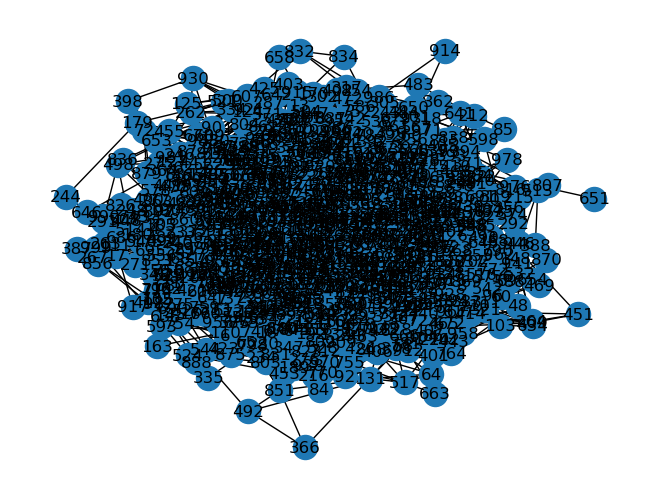

Finding the data from the row graph's subgraph
Finding the diameter of the graph...
Diameter found in 1.0762066841125488 s
Finding the nodes tha are separated by this distance...
Diameter nodes : [131, 335, 366, 492, 542, 651, 663, 688, 722, 832, 851, 914]
Nodes found in 1.070406436920166 s
Finding the nodes (s, e) for the algorithm...
(s, e) found in 0.003223896026611328 s
Finding the distances of all the nodes from e...
Distances from e found in 0.0012176036834716797 s
Finding the neighbors of all the nodes in the row graph...
Neighbors found in 0.0012583732604980469 s
Done with the row graph's subgraph
-------0-------
-------1-------
-------2-------
-------3-------
-------4-------
-------5-------
-------6-------
-------7-------
-------8-------
-------9-------
-------10-------
-------11-------
-------12-------
-------13-------
-------14-------
-------15-------
-------16-------
-------17-------
-------18-------
-------19-------
-------20-------
-------21-------
-------22-------
------

In [164]:
value = 3
if value == 0:
    matrix = np.array([[1,0,1,1,0,0],
                       [0,1,0,1,1,0],
                       [1,0,1,1,0,1],
                       [0,1,0,0,0,0],
                       [0,0,0,1,1,1],
                       [0,0,0,0,0,1]])
elif value == 1:
    matrix = np.array([[1,0,0,1,0,1],
                       [0,1,0,0,1,0],
                       [0,0,1,0,0,1],
                       [0,1,0,0,0,0],
                       [0,0,0,0,1,1],
                       [1,0,1,1,0,1]])
elif value == 2:
    N = 150
    alpha = 1
    M = int(alpha * N)
    sample = 49
    graph = json.load(open(f"N{N}/{sample}.json"))
    clauses = graph["clauses"]
    matrix = np.zeros(shape = (M,N), dtype = int)
    for i, clause in enumerate(clauses):
        matrix[i][clause] = 1
elif value == 3:
    m = 1000  # Number of rows
    n = 1000  # Number of columns
    matrix = np.zeros((m, n), dtype=int)
    for i in range(m):
        row_indices = np.random.choice(n, 3, replace=False)
        matrix[i, row_indices] = 1
    # print(matrix)
    # matrix = np.array([[0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    #                    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    #                    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    #                    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    #                    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    #                    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    #                    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    #                    [0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    #                    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    #                    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0]])
    # for j in range(n):
    #     col_indices = np.random.choice(m, 2, replace=False)
    #     matrix[col_indices, j] = 1

perm = "rows"
verbose = False
show_Gr = True
new_order = msro(matrix,
                 perm = perm,
                 show_Gr = show_Gr,
                 verbose = verbose)
print(new_order)
print(matrix[new_order])